In [6]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AceIQ/data/model_dataset_v2.csv')
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (108342, 18)
Target distribution:
target
1    55460
0    52882
Name: count, dtype: int64


,surface_Clay,surface_Grass,surface_Hard,level_enc,p1_rank,p2_rank,rank_diff,rank_ratio,p1_form,p2_form,form_diff,p1_surface_wr,p2_surface_wr,surface_wr_diff,p1_h2h_wins,p2_h2h_wins,h2h_diff,target
0,0.0,0.0,1.0,2,153.0,220.0,-67.0,0.695455,0.0,0.0,0.0,0.5,0.5,0.0,0,0,0,1
1,0.0,0.0,1.0,2,177.0,182.0,-5.0,0.972527,0.0,0.0,0.0,0.5,0.5,0.0,0,0,0,1
2,0.0,0.0,1.0,2,290.0,133.0,157.0,2.180451,0.0,0.0,0.0,0.5,0.5,0.0,0,0,0,1
3,0.0,0.0,1.0,2,94.0,353.0,-259.0,0.266289,0.0,0.0,0.0,0.5,0.5,0.0,0,0,0,1
4,0.0,0.0,1.0,2,168.0,195.0,-27.0,0.861538,0.0,0.0,0.0,0.5,0.5,0.0,0,0,0,0


In [7]:
from sklearn.model_selection import train_test_split

FEATURES = [
    'surface_Clay', 'surface_Grass', 'surface_Hard',
    'level_enc',
    'p1_rank', 'p2_rank', 'rank_diff', 'rank_ratio',
    'p1_form', 'p2_form', 'form_diff',
    'p1_surface_wr', 'p2_surface_wr', 'surface_wr_diff',
    'p1_h2h_wins', 'p2_h2h_wins', 'h2h_diff',
]

X = df[FEATURES]
y = df['target']

# Temporal split — train on 2015-2022, test on 2023-2024
# We don't use random split because data is time-based
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")

Train: (86673, 17)
Test:  (21669, 17)
Train target distribution:
target
1    44495
0    42178
Name: count, dtype: int64


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

[0]	validation_0-logloss:0.68798


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:04:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.63361
[100]	validation_0-logloss:0.63227
[150]	validation_0-logloss:0.63259
[200]	validation_0-logloss:0.63270
[250]	validation_0-logloss:0.63294
[299]	validation_0-logloss:0.63322

Accuracy:  63.48%
ROC-AUC:   0.6899

              precision    recall  f1-score   support

           0       0.63      0.64      0.63     10704
           1       0.64      0.63      0.63     10965

    accuracy                           0.63     21669
   macro avg       0.63      0.63      0.63     21669
weighted avg       0.64      0.63      0.63     21669



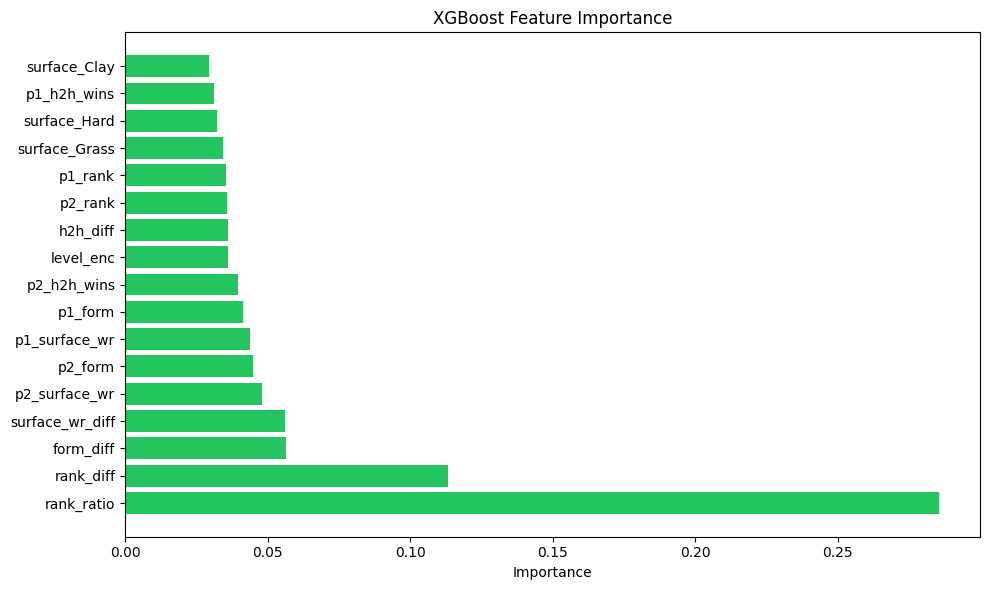

            feature  importance
7        rank_ratio    0.285623
6         rank_diff    0.113128
10        form_diff    0.056323
13  surface_wr_diff    0.056233
12    p2_surface_wr    0.048009
9           p2_form    0.045041
11    p1_surface_wr    0.043853
8           p1_form    0.041498
15      p2_h2h_wins    0.039568
3         level_enc    0.036031
16         h2h_diff    0.035992
5           p2_rank    0.035891
4           p1_rank    0.035353
1     surface_Grass    0.034529
2      surface_Hard    0.032228
14      p1_h2h_wins    0.031120
0      surface_Clay    0.029582


In [9]:
import matplotlib.pyplot as plt

# Feature importance
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='#22c55e')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance)

In [10]:
import numpy as np

df['log_p1_rank'] = np.log1p(df['p1_rank'])
df['log_p2_rank'] = np.log1p(df['p2_rank'])
df['log_rank_diff'] = df['log_p1_rank'] - df['log_p2_rank']

FEATURES = [
    'surface_Clay', 'surface_Grass', 'surface_Hard',
    'level_enc',
    'log_p1_rank', 'log_p2_rank', 'rank_diff', 'log_rank_diff',
    'p1_form', 'p2_form', 'form_diff',
    'p1_surface_wr', 'p2_surface_wr', 'surface_wr_diff',
    'p1_h2h_wins', 'p2_h2h_wins', 'h2h_diff',
]

X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")

[0]	validation_0-logloss:0.68798


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:05:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.63374
[100]	validation_0-logloss:0.63247
[150]	validation_0-logloss:0.63261
[200]	validation_0-logloss:0.63268
[250]	validation_0-logloss:0.63291
[299]	validation_0-logloss:0.63321
Accuracy: 63.49%
ROC-AUC:  0.6900


In [13]:
df = pd.read_csv('/content/drive/MyDrive/AceIQ/data/model_dataset_v3.csv')

FEATURES = [
    'surface_Clay', 'surface_Grass', 'surface_Hard',
    'level_enc',
    'elo_diff',
    'surface_elo_diff',
    'p1_surface_elo', 'p2_surface_elo',
    'form_diff',
    'p1_form', 'p2_form',
    'surface_wr_diff',
    'h2h_diff',
    'p1_h2h_wins', 'p2_h2h_wins',
]

X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

[0]	validation_0-logloss:0.68753
[50]	validation_0-logloss:0.63011
[100]	validation_0-logloss:0.62868
[150]	validation_0-logloss:0.62876
[200]	validation_0-logloss:0.62889
[250]	validation_0-logloss:0.62943
[299]	validation_0-logloss:0.62956

Accuracy: 64.31%
ROC-AUC:  0.6985

              precision    recall  f1-score   support

           0       0.64      0.63      0.63     10704
           1       0.64      0.66      0.65     10965

    accuracy                           0.64     21669
   macro avg       0.64      0.64      0.64     21669
weighted avg       0.64      0.64      0.64     21669



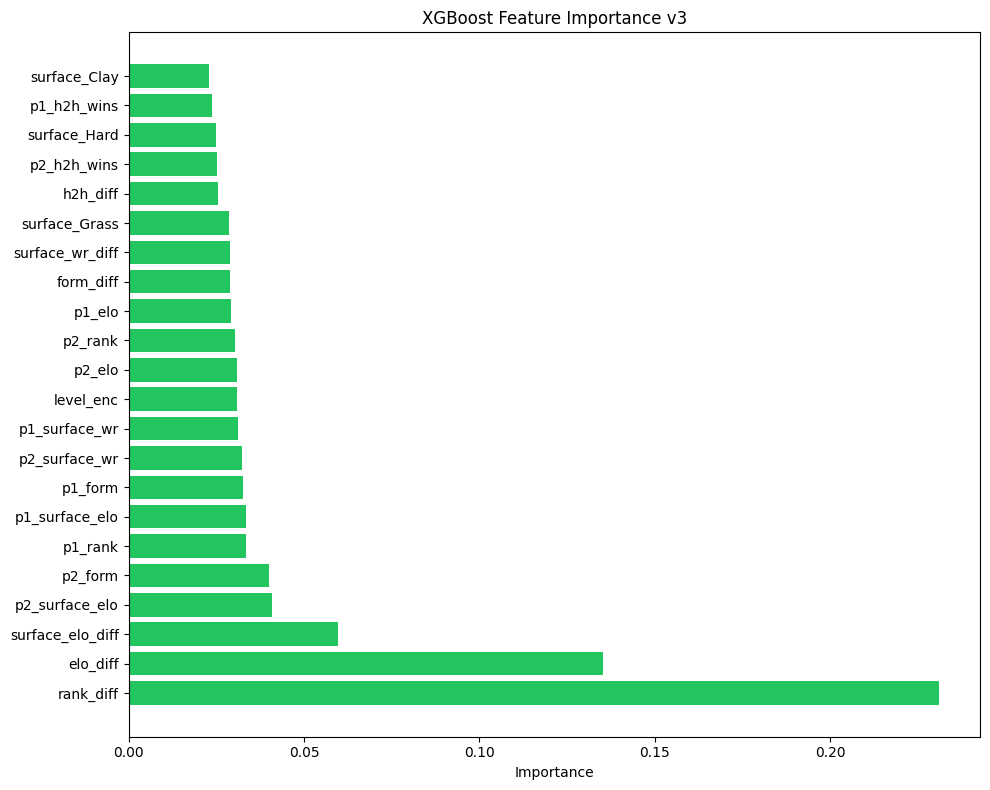

             feature  importance
6          rank_diff    0.231220
9           elo_diff    0.135195
12  surface_elo_diff    0.059623
11    p2_surface_elo    0.040957
14           p2_form    0.039982
4            p1_rank    0.033438
10    p1_surface_elo    0.033321
13           p1_form    0.032676
17     p2_surface_wr    0.032320
16     p1_surface_wr    0.031177
3          level_enc    0.030955
8             p2_elo    0.030829
5            p2_rank    0.030191
7             p1_elo    0.029161
15         form_diff    0.028971
18   surface_wr_diff    0.028795
1      surface_Grass    0.028724
21          h2h_diff    0.025598
20       p2_h2h_wins    0.025184
2       surface_Hard    0.024906
19       p1_h2h_wins    0.023839
0       surface_Clay    0.022938


In [12]:
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='#22c55e')
plt.title('XGBoost Feature Importance v3')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance)